In [ ]:
!pip uninstall -y datasets huggingface_hub transformers -q

!pip install -q \
datasets==3.6.0 \
huggingface_hub==0.32.4 \
transformers==4.52.4 \
tokenizers

print("Environment ready. Restart runtime once after this cell.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.1/512.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 61.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.32.4 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.32.4 which is incompatible.
Environment ready. Restart runtime once after this cell.


In [ ]:
import math, time, os, json
from pathlib import Path
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import GPT2TokenizerFast
import matplotlib.pyplot as plt
import numpy as np

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
CFG = {
    # Data
    "seq_len"     : 256,   # tokens per sample (context window)
    "batch_size"  : 8,    # ← reduce to 8 if OOM
    "num_workers" : 2,
    # Architecture
    "vocab_size"  : 50257, # GPT-2 BPE vocab
    "d_model"     : 256,   # embedding dim
    "n_heads"     : 8,     # attention heads (d_model/n_heads = 32)
    "n_layers"    : 4,     # Transformer blocks
    "d_ff"        : 1024,  # FFN inner dim (4 × d_model)
    "dropout"     : 0.1,
    # Training
    "epochs"      : 5,
    "lr"          : 3e-4,
    "warmup_steps": 1000,
    "grad_clip"   : 1.0,
    "weight_decay": 0.01,
    # Logging
    "log_every"   : 100,
    "eval_every"  : 500,
    "save_dir"    : "./checkpoints",
}
print("\n".join(f"  {k:<18}= {v}" for k,v in CFG.items()))

  seq_len           = 256
  batch_size        = 8
  num_workers       = 2
  vocab_size        = 50257
  d_model           = 256
  n_heads           = 8
  n_layers          = 4
  d_ff              = 1024
  dropout           = 0.1
  epochs            = 5
  lr                = 0.0003
  warmup_steps      = 1000
  grad_clip         = 1.0
  weight_decay      = 0.01
  log_every         = 100
  eval_every        = 500
  save_dir          = ./checkpoints


In [ ]:
print("Loading WikiText-2...")

try:
    raw = load_dataset(
        "Salesforce/wikitext",
        "wikitext-2-raw-v1"
    )
except:
    raw = load_dataset(
        "wikitext",
        "wikitext-2-raw-v1"
    )

print("Loading GPT-2 tokenizer …")
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
print(f"  Vocab size : {tokenizer.vocab_size:,}")


class WikiTextDataset(Dataset):
    """Tokenise a WikiText split into non-overlapping seq_len chunks."""

    def __init__(self, hf_split, tokenizer, seq_len: int):
        self.seq_len = seq_len
        # 1. Join non-empty docs with EOS separator
        texts = [s["text"] for s in hf_split if s["text"].strip()]
        full  = f" {tokenizer.eos_token} ".join(texts)
        print(f"  Tokenising {len(texts):,} docs …")
        # 2. Tokenise entire corpus (no truncation)
        ids = tokenizer(full, return_tensors="pt",
                        truncation=False, add_special_tokens=False)["input_ids"].squeeze(0)
        print(f"  Total tokens : {len(ids):,}")
        # 3. Keep only tokens that fit perfectly into windows
        n = (len(ids) - 1) // seq_len
        self.data = ids[: n * seq_len + 1]
        print(f"  Windows : {n:,}")

    def __len__(self):
        return (len(self.data) - 1) // self.seq_len

    def __getitem__(self, i):
        s = i * self.seq_len
        return self.data[s : s+self.seq_len], self.data[s+1 : s+self.seq_len+1]


print("\nBuilding splits …")
train_ds = WikiTextDataset(raw["train"],      tokenizer, CFG["seq_len"])
valid_ds = WikiTextDataset(raw["validation"], tokenizer, CFG["seq_len"])
test_ds  = WikiTextDataset(raw["test"],       tokenizer, CFG["seq_len"])

kw = dict(num_workers=CFG["num_workers"], pin_memory=True)
train_loader = DataLoader(train_ds, CFG["batch_size"],   shuffle=True,  **kw)
valid_loader = DataLoader(valid_ds, CFG["batch_size"]*2, shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  CFG["batch_size"]*2, shuffle=False, **kw)
print(f"Train batches : {len(train_loader):,}   Valid batches : {len(valid_loader):,}")

Loading WikiText-2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

  Vocab size : 50,257

Building splits …
  Tokenising 23,767 docs …


Token indices sequence length is longer than the specified maximum sequence length for this model (2463182 > 1024). Running this sequence through the model will result in indexing errors


  Total tokens : 2,463,182
  Windows : 9,621
  Tokenising 2,461 docs …
  Total tokens : 254,669
  Windows : 994
  Tokenising 2,891 docs …
  Total tokens : 291,957
  Windows : 1,140
Train batches : 1,203   Valid batches : 63


In [ ]:
# ── Multi-Head Self-Attention ─────────────────────────────────────────────────
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model; self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.scale   = self.d_head ** -0.5
        # Fused Q,K,V projection (faster than 3 separate linears)
        self.qkv        = nn.Linear(d_model, 3*d_model, bias=False)
        self.out_proj   = nn.Linear(d_model, d_model,   bias=False)
        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        # Project and split into Q, K, V
        q, k, v = self.qkv(x).split(self.d_model, dim=-1)
        # Reshape to (B, n_heads, T, d_head)
        rsh = lambda t: t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        q, k, v = rsh(q), rsh(k), rsh(v)
        # Scaled dot-product scores
        scores = torch.matmul(q, k.transpose(-2,-1)) * self.scale    # (B, H, T, T)
        # Causal mask: future positions → -inf
        mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float("-inf"))
        # Softmax → attention weights → weighted sum of V
        w   = self.attn_drop(F.softmax(scores, dim=-1))
        out = torch.matmul(w, v).transpose(1,2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(out)), w   # return weights for visualisation


# ── Feed-Forward Network ──────────────────────────────────────────────────────
class FeedForward(nn.Module):
    """Linear → GELU → Dropout → Linear → Dropout  (applied per token)"""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)


# ── Transformer Block ─────────────────────────────────────────────────────────
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ln2  = nn.LayerNorm(d_model)
        self.ff   = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        a, w = self.attn(self.ln1(x));  x = x + a   # residual
        x    = x + self.ff(self.ln2(x))              # residual
        return x, w


# ── Full Language Model ───────────────────────────────────────────────────────
class DecoderOnlyTransformer(nn.Module):
    """GPT-style language model: token emb + pos emb + blocks + LM head."""

    def __init__(self, cfg):
        super().__init__()
        D, V, T = cfg["d_model"], cfg["vocab_size"], cfg["seq_len"]
        self.tok_emb = nn.Embedding(V, D)
        self.pos_emb = nn.Embedding(T, D)   # learned positional embedding
        self.drop    = nn.Dropout(cfg["dropout"])
        self.blocks  = nn.ModuleList([
            TransformerBlock(D, cfg["n_heads"], cfg["d_ff"], cfg["dropout"])
            for _ in range(cfg["n_layers"])
        ])
        self.ln_f    = nn.LayerNorm(D)
        self.lm_head = nn.Linear(D, V, bias=False)
        # Weight tying: lm_head shares weights with tok_emb
        # → reduces params, improves perplexity
        self.lm_head.weight = self.tok_emb.weight
        self.apply(self._init_weights)
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Parameters: {n:,}  (~{n/1e6:.1f}M)")

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0, 0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding): nn.init.normal_(m.weight, 0, 0.02)
        elif isinstance(m, nn.LayerNorm): nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, idx):
        B, T = idx.shape
        # Sum token and positional embeddings
        x = self.drop(
            self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))
        )
        attn_list = []
        for blk in self.blocks:
            x, w = blk(x); attn_list.append(w)
        # Project to vocabulary
        logits = self.ln_f(x) @ self.lm_head.weight.T   # (B, T, V)
        return logits, attn_list


# Instantiate
model = DecoderOnlyTransformer(CFG).to(DEVICE)

# Quick sanity check
_x = torch.randint(0, CFG["vocab_size"], (2, CFG["seq_len"]), device=DEVICE)
_logits, _attn = model(_x)
print(f"Output: {_logits.shape}  (expect (2, 512, 50257))")
del _x, _logits, _attn

Parameters: 16,086,784  (~16.1M)
Output: torch.Size([2, 256, 50257])  (expect (2, 512, 50257))


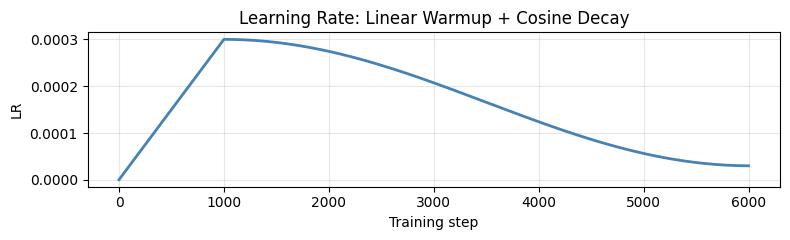

Decay params    : 3,145,728
No-decay params : 12,941,056


In [ ]:
# ── Cross-entropy loss ───────────────────────────────────────────────────────
def compute_loss(logits, targets):
    """Flatten (B,T,V)→(B*T,V) and (B,T)→(B*T) then cross-entropy."""
    B, T, V = logits.shape
    return F.cross_entropy(logits.reshape(B*T, V),targets.reshape(B*T))

# ── LR: linear warmup → cosine decay ─────────────────────────────────────────
def get_lr(step, total_steps):
    w, hi, lo = CFG["warmup_steps"], CFG["lr"], CFG["lr"]*0.1
    if step < w:
        return hi * (step+1) / w        # linear warmup
    prog = min((step-w) / max(1, total_steps-w), 1.0)
    return lo + 0.5*(hi-lo)*(1 + math.cos(math.pi*prog))   # cosine decay

# Visualise schedule
_n  = CFG["epochs"] * len(train_loader)
_ss = range(0, _n, max(1, _n//300))
plt.figure(figsize=(8, 2.5))
plt.plot(list(_ss), [get_lr(s, _n) for s in _ss], color="steelblue", lw=2)
plt.xlabel("Training step"); plt.ylabel("LR")
plt.title("Learning Rate: Linear Warmup + Cosine Decay"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("lr_schedule.png", dpi=120); plt.show()

# ── AdamW with weight-decay only on 2-D+ tensors ─────────────────────────────
# DO NOT decay biases, LayerNorm params, or embeddings
decay, no_decay = [], []
for name, p in model.named_parameters():
    if not p.requires_grad: continue
    if p.dim() == 1 or any(k in name for k in ("ln","bias","emb")):
        no_decay.append(p)
    else:
        decay.append(p)

optimiser = torch.optim.AdamW(
    [{"params": decay,    "weight_decay": CFG["weight_decay"]},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=CFG["lr"], betas=(0.9, 0.95), eps=1e-8,
)
print(f"Decay params    : {sum(p.numel() for p in decay):,}")
print(f"No-decay params : {sum(p.numel() for p in no_decay):,}")

In [ ]:
os.makedirs(CFG["save_dir"], exist_ok=True)

# ── Checkpoint helpers ────────────────────────────────────────────────────────
def save_ckpt(step, epoch, history):
    p = f"{CFG['save_dir']}/step_{step:06d}.pt"
    torch.save({"step":step,"epoch":epoch,
                "model":model.state_dict(),"opt":optimiser.state_dict(),
                "history":history, "cfg":CFG}, p)
    print(f"  ✔  Saved → {p}")

def load_ckpt(path):
    c = torch.load(path, map_location=DEVICE)
    model.load_state_dict(c["model"]); optimiser.load_state_dict(c["opt"])
    print(f"  ✔  Resumed  step={c['step']}  epoch={c['epoch']}")
    return c["step"], c["epoch"], c["history"]

# ── Evaluation ────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(loader):
    model.eval(); tot = 0; n = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits, _ = model(x)
        tot += compute_loss(logits, y).item(); n += 1
    model.train()
    avg = tot / n
    return {"loss": avg, "ppl": math.exp(avg)}

# ── Training loop ─────────────────────────────────────────────────────────────
def train(start_step=0, start_epoch=0, history=None):
    if history is None:
        history = {"tl":[], "ts":[], "vl":[], "vp":[], "vs":[]}
    total = CFG["epochs"] * len(train_loader)
    step  = start_step
    model.train()

    for ep in range(start_epoch, CFG["epochs"]):
        ep_loss = ep_n = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            # 1. Update LR
            for pg in optimiser.param_groups:
                pg["lr"] = get_lr(step, total)

            # 2. Forward pass
            logits, _ = model(x)
            loss = compute_loss(logits, y)

            # 3. Backward + gradient clip + update
            optimiser.zero_grad()
            loss.backward()
            gn = nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
            optimiser.step()

            # 4. Logging
            lv = loss.item(); ep_loss += lv; ep_n += 1
            history["tl"].append(lv); history["ts"].append(step)

            if step % CFG["log_every"] == 0:
                lr_now = get_lr(step, total)
                print(f"Ep {ep+1}/{CFG['epochs']} | Step {step:6d} | "
                      f"Loss {lv:.4f} | PPL {math.exp(lv):.1f} | "
                      f"LR {lr_now:.2e} | GradNorm {gn:.2f}")

            # 5. Validation
            if step % CFG["eval_every"] == 0 and step > 0:
                vm = evaluate(valid_loader)
                history["vl"].append(vm["loss"])
                history["vp"].append(vm["ppl"])
                history["vs"].append(step)
                print(f"  ▶ VALID  Loss {vm['loss']:.4f}  PPL {vm['ppl']:.2f}")

            # 6. Checkpoint
            if step % (CFG["eval_every"]*2) == 0 and step > 0:
                save_ckpt(step, ep, history)

            step += 1

        ep_avg = ep_loss / ep_n
        print(f"\n══ Epoch {ep+1}/{CFG['epochs']}  "
              f"AvgLoss={ep_avg:.4f}  PPL={math.exp(ep_avg):.2f} ══\n")

    save_ckpt(step, CFG["epochs"], history)
    return history


# TO RESUME after disconnect — uncomment:
# step0, epoch0, hist0 = load_ckpt("checkpoints/step_XXXXXX.pt")
# history = train(start_step=step0, start_epoch=epoch0, history=hist0)
print("Functions defined. Run next cell to start training.")

Functions defined. Run next cell to start training.


In [ ]:
print(f"Total training steps : {CFG['epochs']*len(train_loader):,}")
print("Starting training ...\n")
history = train()
print("\nTraining complete.")

Total training steps : 6,015
Starting training ...

Ep 1/5 | Step      0 | Loss 10.8673 | PPL 52431.4 | LR 3.00e-07 | GradNorm 2.23
Ep 1/5 | Step    100 | Loss 10.0560 | PPL 23295.3 | LR 3.03e-05 | GradNorm 1.52
Ep 1/5 | Step    200 | Loss 8.7151 | PPL 6094.3 | LR 6.03e-05 | GradNorm 1.59
Ep 1/5 | Step    300 | Loss 7.4455 | PPL 1712.2 | LR 9.03e-05 | GradNorm 1.13
Ep 1/5 | Step    400 | Loss 6.7973 | PPL 895.4 | LR 1.20e-04 | GradNorm 0.76
Ep 1/5 | Step    500 | Loss 6.7444 | PPL 849.3 | LR 1.50e-04 | GradNorm 0.69
  ▶ VALID  Loss 6.7459  PPL 850.54
Ep 1/5 | Step    600 | Loss 6.6593 | PPL 780.0 | LR 1.80e-04 | GradNorm 0.94
Ep 1/5 | Step    700 | Loss 6.6287 | PPL 756.5 | LR 2.10e-04 | GradNorm 0.91
Ep 1/5 | Step    800 | Loss 6.2395 | PPL 512.6 | LR 2.40e-04 | GradNorm 0.93
Ep 1/5 | Step    900 | Loss 6.1258 | PPL 457.5 | LR 2.70e-04 | GradNorm 0.84
Ep 1/5 | Step   1000 | Loss 6.2665 | PPL 526.6 | LR 3.00e-04 | GradNorm 0.96
  ▶ VALID  Loss 6.2355  PPL 510.54
  ✔  Saved → ./checkpoi

In [ ]:
# ── Test-set evaluation (do this ONCE, after all tuning) ─────────────────────
print("Test set evaluation …")
tm = evaluate(test_loader)
print(f"  Test Loss : {tm['loss']:.4f}")
print(f"  Test PPL  : {tm['ppl']:.2f}")

# ── Throughput: tokens processed per second ───────────────────────────────────
# Used in Phase 2 to compare attention variants
print("\nMeasuring throughput (20 batches) …")
model.train()
_opt = torch.optim.SGD(model.parameters(), lr=1e-4)
# warm-up pass
_x0, _y0 = next(iter(train_loader))
_x0, _y0 = _x0.to(DEVICE), _y0.to(DEVICE)
compute_loss(model(_x0)[0], _y0).backward(); _opt.zero_grad()

if DEVICE.type == "cuda": torch.cuda.synchronize()
t0 = time.perf_counter(); tok = 0
for i, (x, y) in enumerate(train_loader):
    if i >= 20: break
    x, y = x.to(DEVICE), y.to(DEVICE)
    compute_loss(model(x)[0], y).backward(); _opt.zero_grad()
    tok += x.numel()
if DEVICE.type == "cuda": torch.cuda.synchronize()
tps = tok / (time.perf_counter() - t0)
print(f"  Throughput : {tps:,.0f} tokens/second")

# ── Summary table ─────────────────────────────────────────────────────────────
bvp = min(history["vp"]) if history["vp"] else float("nan")
print("\n" + "="*60)
print("PHASE 1 RESULTS SUMMARY")
print("="*60)
print(f"{'Model':<28}  {'Val PPL':>8}  {'Test PPL':>8}  {'t/s':>12}")
print("-"*60)
print(f"{'Transformer Baseline':<28}  {bvp:>8.2f}  {tm['ppl']:>8.2f}  {tps:>9,.0f}")
print("="*60)

# Save for Phase 2 comparison
with open("phase1_summary.json","w") as f:
    json.dump({"model":"transformer_baseline","config":CFG,
               "best_val_ppl":bvp,"test_ppl":tm["ppl"],
               "throughput_tps":tps},f,indent=2)
print("\n→  Saved phase1_summary.json  (load in Phase 2 for comparison)")

Test set evaluation …
  Test Loss : 5.5088
  Test PPL  : 246.84

Measuring throughput (20 batches) …
  Throughput : 23,786 tokens/second

PHASE 1 RESULTS SUMMARY
Model                          Val PPL  Test PPL           t/s
------------------------------------------------------------
Transformer Baseline            244.46    246.84     23,786

→  Saved phase1_summary.json  (load in Phase 2 for comparison)


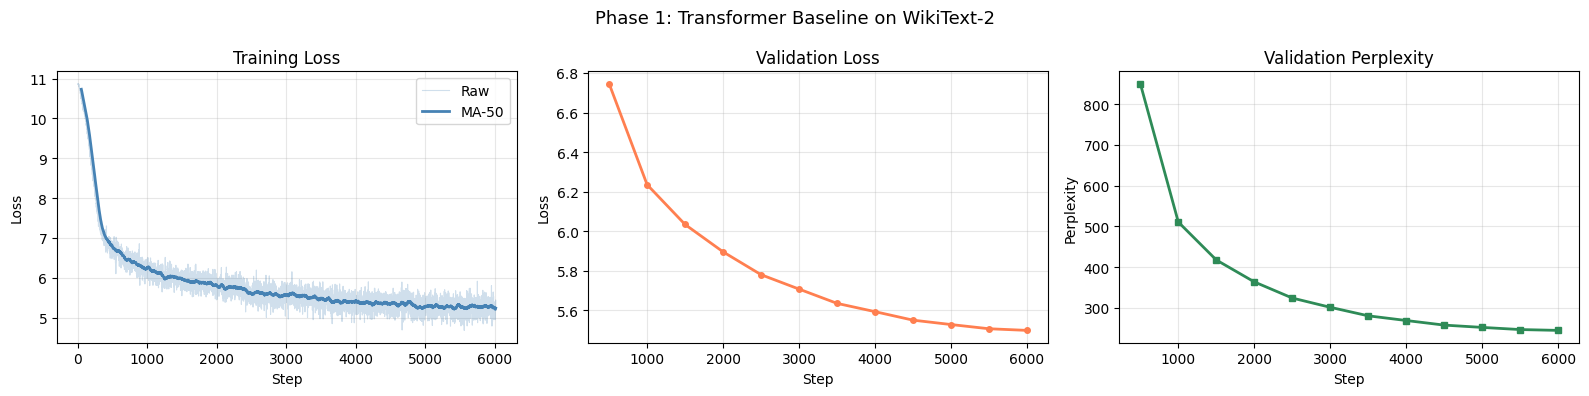

Saved → training_curves.png

Attention heatmaps (early and late layer) …


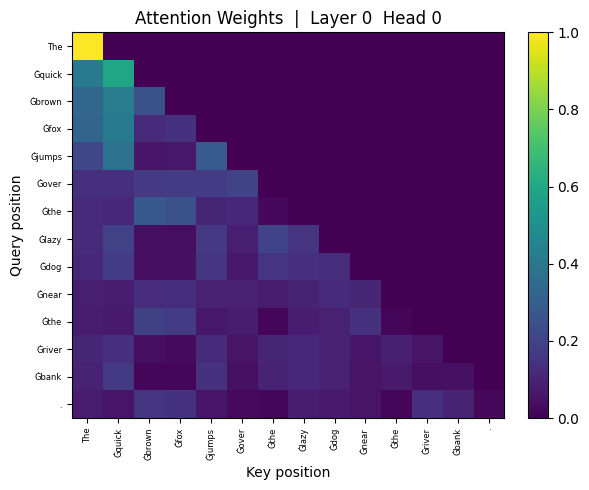

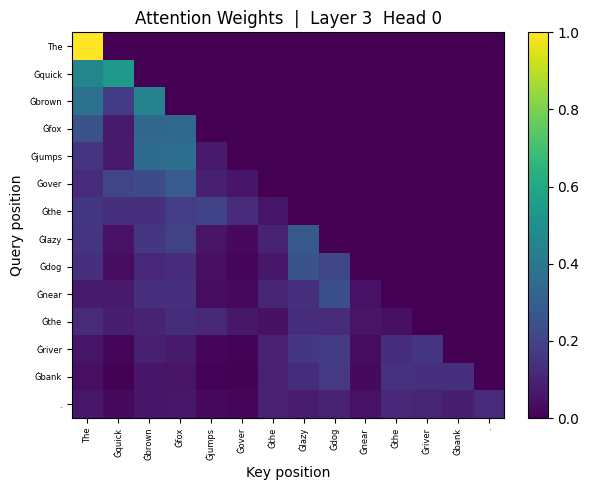

In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(history["ts"], history["tl"], alpha=0.25, color="steelblue", lw=0.8, label="Raw")
if len(history["tl"]) > 50:
    sm = np.convolve(history["tl"], np.ones(50)/50, "valid")
    ax.plot(history["ts"][49:], sm, color="steelblue", lw=2, label="MA-50")
ax.set(xlabel="Step", ylabel="Loss", title="Training Loss"); ax.grid(alpha=0.3); ax.legend()

ax = axes[1]
ax.plot(history["vs"], history["vl"], "o-", color="coral", lw=2, ms=4)
ax.set(xlabel="Step", ylabel="Loss", title="Validation Loss"); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(history["vs"], history["vp"], "s-", color="seagreen", lw=2, ms=4)
ax.set(xlabel="Step", ylabel="Perplexity", title="Validation Perplexity"); ax.grid(alpha=0.3)

plt.suptitle("Phase 1: Transformer Baseline on WikiText-2", fontsize=13)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved → training_curves.png")

# ── Attention heatmap ─────────────────────────────────────────────────────────
@torch.no_grad()
def plot_attn(text, layer=0, head=0):
    model.eval()
    ids = tokenizer(text, return_tensors="pt")["input_ids"][:, :CFG["seq_len"]].to(DEVICE)
    _, attn_list = model(ids)
    attn = attn_list[layer][0, head].cpu().numpy()
    toks = tokenizer.convert_ids_to_tokens(ids[0].tolist())
    T = len(toks)
    fig, ax = plt.subplots(figsize=(max(6, T*0.4), max(5, T*0.35)))
    im = ax.imshow(attn, cmap="viridis", aspect="auto")
    ax.set_xticks(range(T)); ax.set_yticks(range(T))
    ax.set_xticklabels(toks, rotation=90, fontsize=6)
    ax.set_yticklabels(toks, fontsize=6)
    ax.set_xlabel("Key position"); ax.set_ylabel("Query position")
    ax.set_title(f"Attention Weights  |  Layer {layer}  Head {head}")
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.savefig(f"attn_l{layer}_h{head}.png", dpi=120); plt.show()
    model.train()

SAMPLE = "The quick brown fox jumps over the lazy dog near the river bank."
print("\nAttention heatmaps (early and late layer) …")
plot_attn(SAMPLE, layer=0, head=0)
plot_attn(SAMPLE, layer=CFG["n_layers"]-1, head=0)